### 1.0 Introduction
Food supply patterns can provide valuable insights into dietary habits and nutritional transitions across countries. The data used for analysis is sourced from the Food and Agriculture Organization Statistical Database (FAOSTAT) Food Balance Sheets, ranging from 2010 to 2023. The analysis focused on three major food categories: plant-based foods, animal-based foods, and sugar. The analysis was conducted via Databricks with Apache Hive employed for data querying and Python used for data cleaning and visualization.

**Link to dataset**: https://www.fao.org/faostat/en/?utm_source=chatgpt.com#data/FBS

### 2.0 Problem Statement
Dietary patterns are continuously evolving globally due to urbanization, economic development, globalization, and shifitng of consumer preferences. Understanding how sugar consumption and protein sources have changed over time is important for assessing nutritional transitions and identifying emerging food market trends. However, significant differences may exist between countries due to variations in food systems, agricultural productions, and socioeconomic conditions.

The objectives of this study are:

1. To analyze global sugar supply trends and identify countries with the highest per-capita sugar supply.
2. To assess the temporal changes of plant-based and animal-based protein supplies.
3. To investigate the distribution of calorie supply across food categories.
4. To provide insights into global dietary transition patterns and their potentials for market development.

### 3.0 Data Import
The dataset used in this study was stored as a comma-separated values (CSV) file and imported into the Python environment via pandas library.

In [0]:
#Data Loading
import pandas as pd
df = pd.read_csv("/Workspace/STDQ6324_Data_Management/FAOSTAT_data_new.csv")
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (FBS),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,FBS,Food Balances (2010-),4,Afghanistan,664,Food supply (kcal/capita/day),S2905,Cereals - Excluding Beer,2010,2010,kcal/cap/d,1648.94,E,Estimated value,NaN
1,FBS,Food Balances (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),S2905,Cereals - Excluding Beer,2010,2010,g/cap/d,47.98,E,Estimated value,NaN
2,FBS,Food Balances (2010-),4,Afghanistan,664,Food supply (kcal/capita/day),S2905,Cereals - Excluding Beer,2011,2011,kcal/cap/d,1600.17,E,Estimated value,NaN
3,FBS,Food Balances (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),S2905,Cereals - Excluding Beer,2011,2011,g/cap/d,46.52,E,Estimated value,NaN
4,FBS,Food Balances (2010-),4,Afghanistan,664,Food supply (kcal/capita/day),S2905,Cereals - Excluding Beer,2012,2012,kcal/cap/d,1543.38,E,Estimated value,NaN


#### 3.1 Data Cleaning
Only columns relevant for analysis were retained including "Area", "Item", "Element", "Year", and "Value". The dataset information showed that the five aforementioned columns were successfully retained with a total of 29100 observations with no missing values identified. The data is also checked for data duplications which is absent from this dataset. 

#### 3.2 Data Description
The "Item" column consisted of six food groups which are then categorized into three categories (sugar, plant-based, animal-based) in later analysis. These include "Cereals - Excluding Beer", "Sugar & Sweeteners", "Pulses", "Meat", "Eggs", and "Fish, Seafood". Furthermore, the "Element" column comprised of the "Food supply (kcal/capita/day)" which represent the daily calorie supply per capita for each food and "Protein supply quantity (g/capita/day)" that represent the amount of protein provided per capita for each person. Lastly, a total of 179 countries were analyzed in this study.

In [0]:
#Keep only relevant columns
df = df[['Area', 'Item', 'Element', 'Year', 'Value']]
df.head()

,Area,Item,Element,Year,Value
0,Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2010,1648.94
1,Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2010,47.98
2,Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2011,1600.17
3,Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2011,46.52
4,Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2012,1543.38


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29100 entries, 0 to 29099
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Area     29100 non-null  object 
 1   Item     29100 non-null  object 
 2   Element  29100 non-null  object 
 3   Year     29100 non-null  int64  
 4   Value    29100 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 1.1+ MB


In [0]:
#Check for duplication
df.duplicated().sum()

np.int64(0)

In [0]:
#Exploratory Data Analysis
df['Item'].unique()

array(['Cereals - Excluding Beer', 'Sugar & Sweeteners', 'Pulses', 'Meat',
       'Eggs', 'Fish, Seafood'], dtype=object)

In [0]:
df['Element'].unique()

array(['Food supply (kcal/capita/day)',
       'Protein supply quantity (g/capita/day)'], dtype=object)

In [0]:
#number of unique countries
df['Area'].nunique()

179

#### 3.3 Data Preprocessing
A new column "Food_Type" was added into the table by labelling the individual food group in "Item" column into three categories:

1. Plant-based:
    - cereals
    - pulses
2. Animal-based:
    - meat
    - eggs
    - fish, seafood
3. Sugar:
    - sugar & sweeteners

In [0]:
#Create food categories
def food_category(item):
    if item in ['Cereals - Excluding Beer',
                'Pulses']:
        return 'plant-based'
    elif item in ['Meat', 'Eggs', 'Fish, Seafood']:
        return 'animal-based'
    elif item == 'Sugar & Sweeteners':
        return 'sugar'
    else:
        return 'other'
df['Food_Type'] = df['Item'].apply(food_category)
df.head()

,Area,Item,Element,Year,Value,Food_Type
0,Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2010,1648.94,plant-based
1,Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2010,47.98,plant-based
2,Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2011,1600.17,plant-based
3,Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2011,46.52,plant-based
4,Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2012,1543.38,plant-based


In [0]:
#Verification
df[['Item', 'Food_Type']].drop_duplicates()

,Item,Food_Type
0,Cereals - Excluding Beer,plant-based
28,Sugar & Sweeteners,sugar
56,Pulses,plant-based
84,Meat,animal-based
112,Eggs,animal-based
140,"Fish, Seafood",animal-based


#### 3.4 Apache Hive Temporary View Creation
The cleaned dataset was converted into a Spark DataFrame and stored as a temporary Hive view name "food". This enabled Hive queries to be executed directly on the dataset for subsequent analyses.

In [0]:
#Apache Hive
#Convert Pandas DF into Spark DF
spark_df = spark.createDataFrame(df)
spark_df.createOrReplaceTempView("food")

In [0]:
%sql
SELECT *
FROM food
LIMIT 10

Area,Item,Element,Year,Value,Food_Type
Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2010,1648.94,plant-based
Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2010,47.98,plant-based
Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2011,1600.17,plant-based
Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2011,46.52,plant-based
Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2012,1543.38,plant-based
Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2012,44.86,plant-based
Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2013,1568.96,plant-based
Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2013,45.65,plant-based
Afghanistan,Cereals - Excluding Beer,Food supply (kcal/capita/day),2014,1552.38,plant-based
Afghanistan,Cereals - Excluding Beer,Protein supply quantity (g/capita/day),2014,44.89,plant-based


### 4.0 Hive Queries and Visualization
#### 4.1 Global Sugar Supply Trend (2010-2023)
The trend of global sugar supply between 2010 and 2023 was examined by aggregating annual sugar supply of kcal/capita/day values across all countries to find the average value. This aims to identify changes in sugar availability over time and provide insights into broader dietary transition patterns.

In [0]:
# Query 1: Sugar Supply Over Time
sugar_trend = spark.sql("""

SELECT Year, ROUND(AVG(Value),2) AS Avg_Sugar_Supply
FROM food
WHERE Element = 'Food supply (kcal/capita/day)'
AND Item = 'Sugar & Sweeteners'
GROUP BY Year
ORDER BY Year

""")
display(sugar_trend)

Year,Avg_Sugar_Supply
2010,299.29
2011,299.89
2012,301.21
2013,302.44
2014,299.2
2015,295.42
2016,294.62
2017,296.03
2018,291.66
2019,292.55


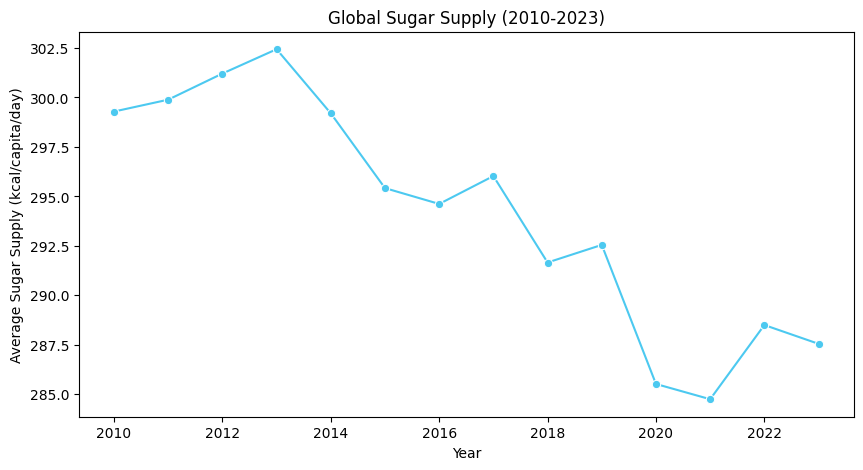

In [0]:
#Convert to Pandas
sugar_trend_df = sugar_trend.toPandas()

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='Avg_Sugar_Supply', data=sugar_trend_df, color = "#4CC9F0", marker='o')
plt.title('Global Sugar Supply (2010-2023)')
plt.xlabel('Year')
plt.ylabel('Average Sugar Supply (kcal/capita/day)')
plt.show()

#### Global sugar supply
The plot above showed declining trend of global sugar supply from year 2010 to year 2023. The supply peaked around 2013 and gradually declined throughout the following years. This may reflect the increased global awareness towards the impact of excessive sugar consumption on health, emphasized and encouraged by the World Health Organization (WHO) to reduce free sugar intakes (WHO, 2015). WHO (2016) reported positive outcomes of increasing implementation of sugar tax particularly the sugar-sweetened beverage (SSB) tax across multiple countries in reducing sugar consumption. The successful case of Mexico in 2014 had resulted in an expansion of SSB adoption globally with more than 40 countries implementing the taxation by 2020 (World Bank, 2020). Evidence demonstrated the effectiveness of such taxes in lowering the sales and purchases of sugary drinks. Furthermore, a more pronounced reduction was observed between 2019 and 2020 which coincides with the COVID-19 pandemic period. Some studies have showed that pandemic had caused a change in eating habits and purchase behaviour of food, shifting towards heathier choices to build immunity against the virus (Baghlaf et al., 2022; Park et al., 2023). Nevertheless, dietary responses during the pandemic were not uniform across all countries and population groups. Increased sugar intake among certain populations, particularly low-income adults in the United States has been reported (ASN staff, 2021; Park et al., 2021). This suggests that the regional and socioeconomic differences in dietary behaviour may be masked by the global average trends.

**References:**
1. ASN staff. (2021, June 8). How a global pandemic changed the way we eat and shop. American Society for Nutrition. https://nutrition.org/how-a-global-pandemic-changed-the-way-we-eat-and-shop/
2. Baghlaf, K., Bormah, D., Hakami, A., & Bagher, S. M. (2022). The impact of the COVID-19 lockdown on sugar-sweetened beverage consumption in children in Saudi Arabia: a mixed-methods study. Nutrients, 14(23), 4972. https://doi.org/10.3390/nu14234972
3. IANS. (2022, March 5). Does the pandemic have anything to do with sugar consumption?. The Economic Times. https://economictimes.indiatimes.com/news/how-to/does-the-pandemic-have-anything-to-do-with-sugar-consumption/articleshow/90016263.cms?from=mdr
4. Park, M., Kim, D., Choi, M., & Shin, J. (2023). Difference in sugar sweetened beverages consumption before and during the COVID-19 pandemic among Korean adolescents. The Journal of Nutrition. https://doi.org/10.1016/j.tjnut.2023.05.007
5. Park, S., Yaroch, A., & Blanck, H. (2021). Changes in consumption of foods and beverages with added sugars during the COVID-19 pandemic among US adults. Current Developments in Nutrition, 5, 242. https://doi.org/10.1093/cdn/nzab029_043
6. World Bank. (2020). Taxes on Sugar-Sweetened Beverages. https://doi.org/10.1596/33969
7. World Health Organization. (2015). Guideline: sugars intake for adults and children. World Health Organization. https://www.who.int/publications/i/item/9789241549028
8. World Health Organization. (2016). Fiscal Policies for Diet and Prevention of Noncommunicable Diseases.


#### 4.2 Countries with Highest Per-Capita Sugar Supply
The top 10 countries with the highest average sugar supply over the study period were identified. Using per-capita measurements allowed meaningful comparison between countries of different population sizes and helped reveal regions with greater dependence on sugar-rich food and sweetened products. This is done by finding the average food supply of the "Sugar & sweeteners" group for each country from 2010 to 2023. The countries are then arranged based their average sugar supply values in descending order. 

In [0]:
# Query 2: Top 10 Countries by Sugar Supply
sugar_supply = spark.sql("""

SELECT Area, ROUND(AVG(Value),2) AS Avg_Sugar_Supply
FROM food
WHERE Element = 'Food supply (kcal/capita/day)'
AND Item = 'Sugar & Sweeteners'
GROUP BY Area
ORDER BY Avg_Sugar_Supply DESC
LIMIT 10

""")
display(sugar_supply)


Area,Avg_Sugar_Supply
United States of America,596.37
Colombia,588.69
Barbados,564.11
New Zealand,543.46
Tuvalu,530.78
Costa Rica,519.16
Malta,515.15
Belgium,510.08
Cuba,509.05
Jamaica,492.68


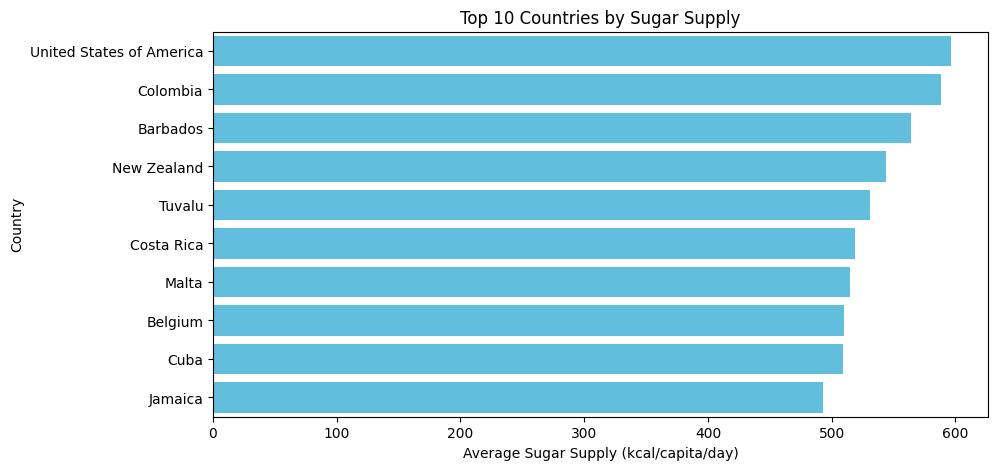

In [0]:
#Convert to Pandas
sugar_supply_df = sugar_supply.toPandas()

#Visualization
plt.figure(figsize=(10,5))
sns.barplot(x='Avg_Sugar_Supply', y='Area', data=sugar_supply_df, color="#4CC9F0")
plt.title('Top 10 Countries by Sugar Supply')
plt.xlabel('Average Sugar Supply (kcal/capita/day)')
plt.ylabel('Country')
plt.show()

#### Countries with highest per-capita sugar supply availability
The country-level analysis revealed that the United States recorded the highest average sugar supply, approaching 600 kcal/capita/day, followed by countries such as Columbia, Barbados, New Zealand, and Tuvalu. These values were higher than the global average sugar supply reported above, which might indicate variation in dietary sugar availability between countries. Despite highly populated countries such as India, were reported for large sugar consumption volumes, they were not included among the top-ranking countries (Helgi Library, 2023). This is mainly due to the nature of dataset used in this study which was standardized using per-capita measurements. Thus, this represents the average sugar supply available per individual rather than total national sugar consumption. Developed countries with high per-capita sugar supply such as the United States and New Zealand may reflect greater dependence on processed and ultra-processed food products, high availability of sugar-sweetened beverages, and highly industrialized food systems (Howard & Henry, 2024; Nyika, 2018). Ultra-processed foods are known to contain high levels of refined sugars and additives which contribute substantially to dietary sugar exposure.  Furthermore, the western diet has often been characterized by energy-dense yet nutrient-poor food, often comprised of fast foods, soft drinks and highly processed foods, rich in added sugar and saturated fats (Clemente-Suarez et al., 2023). This may explain why the top-ranked countries for global sugar supply are mostly the western countries.

The high sugar supply in developing countries like Colombia is mainly caused by the dietary patterns which is further supported by the fact there is a consistent prevalence of diabetes reported (Mendivil et al., 2021). Despite Colombia as a sugar-producing country, this does not elucidate the observed rankings. Brazil as the world's largest sugar producer did not appear among the highest per-capita sugar supply in the current analysis suggests that per-capita sugar supply is likely influenced by factors beyond domestic sugar productions such as dietary behaviour and national food systems. Besides, several Small Island Developing State (SIDS) such as Barbados and Tuvalu exhibited considerably high sugar supply levels, placing third and fifth among the top ranked countries. The primary driving force is the limited land and climatic factors that forces the countries to heavily rely on imported food (Kos-Stanisic et al., 2023; Rafkin, 2018).

**References:**
1. Clemente-Suárez, V. J., Beltrán-Velasco, A. I., Redondo-Flórez, L., Martín-Rodríguez, A., & Tornero-Aguilera, J. F. (2023). Global Impacts of Western Diet and Its Effects on Metabolism and Health: a Narrative Review. Nutrients, 15(12), 2749-2749. https://doi.org/10.3390/nu15122749
2. Helgi Library. (2023, August 25). Which country eats the most sugar & sweeteners?. Helgi Library. https://www.helgilibrary.com/charts/which-country-eats-the-most-sugar-sweeteners/
3. Howard, B., & Henry, K. (2024, December 10). Ultraprocessed foods account for more than half of calories consumed at home. Johns Hopkins Bloomberg School of Public Health. https://publichealth.jhu.edu/2024/ultraprocessed-foods-account-for-more-than-half-of-calories-consumed-at-home
4. Kos-Stanisic, L., Lusa, D., & Zguric, B. (2021). Climate challenges of small island developing states: cases of Tuvalu, Seychelles and Barbados. In Advances in Social Science, Education and Humanities Research (Vol. 606, pp. 220–230). Atlantis Press SARL.
5. Nyika, R. (2018, January 16). Sugary drinks - NZ worse than Canada, UK and Australia, study finds. Stuff. https://www.stuff.co.nz/national/health/100581810/sugary-drinks--nz-worse-than-usa-uk-and-australia-study-finds‌
6. Mendivil, C. O., Romero, S. A. G., Peláez-Jaramillo, M. J., Nieves-Barreto, L. D., Montaño-Rodríguez, A., & Betancourt-Villamizar, E. (2021). Diabetes and associated dietary intake among urban adults: COPEN (Colombian Nutritional Profiles)—a cross-sectional study. BMJ Open, 11(6), e042050. https://doi.org/10.1136/bmjopen-2020-042050
7. Rafkin, K. (2018, February 17). Sustainable Agriculture in Tuvalu. The Borgen Project. https://borgenproject.org/sustainable-agriculture-in-tuvalu/


#### 4.3 Animal-Based vs Plant-Based Protein Supply Trends
The temporal trends of animal-based and plant-based protein supply were compared. In addition, the indexed growth trends are also assessed to evaluate how dietary protein sources evolved over time. The original protein supply trend show the absolute amount of protein supplied but it may not clearly reveal the relative change over time as plant-based and animal-based proteins begin from different baseline values. The index was calculated by dividing the protein supply value each year by its corresponding value in 2010 and multiplying by 100. Values above 100 indicate growth relative to 2010 whereas values below 100 indicate a decline. 

In [0]:
# Query 3: Animal vs Plant Protein Supply Over Time
protein_trend = spark.sql("""

SELECT Year, Food_Type, ROUND(AVG(Value),2) AS Avg_Protein_Supply
FROM food
WHERE Element = 'Protein supply quantity (g/capita/day)'
AND Food_Type IN ('animal-based', 'plant-based')
GROUP BY Year, Food_Type
ORDER BY Year

""")
display(protein_trend)

Year,Food_Type,Avg_Protein_Supply
2010,animal-based,9.54
2010,plant-based,16.39
2011,plant-based,16.34
2011,animal-based,9.59
2012,plant-based,16.32
2012,animal-based,9.65
2013,animal-based,9.68
2013,plant-based,16.37
2014,plant-based,16.29
2014,animal-based,9.77


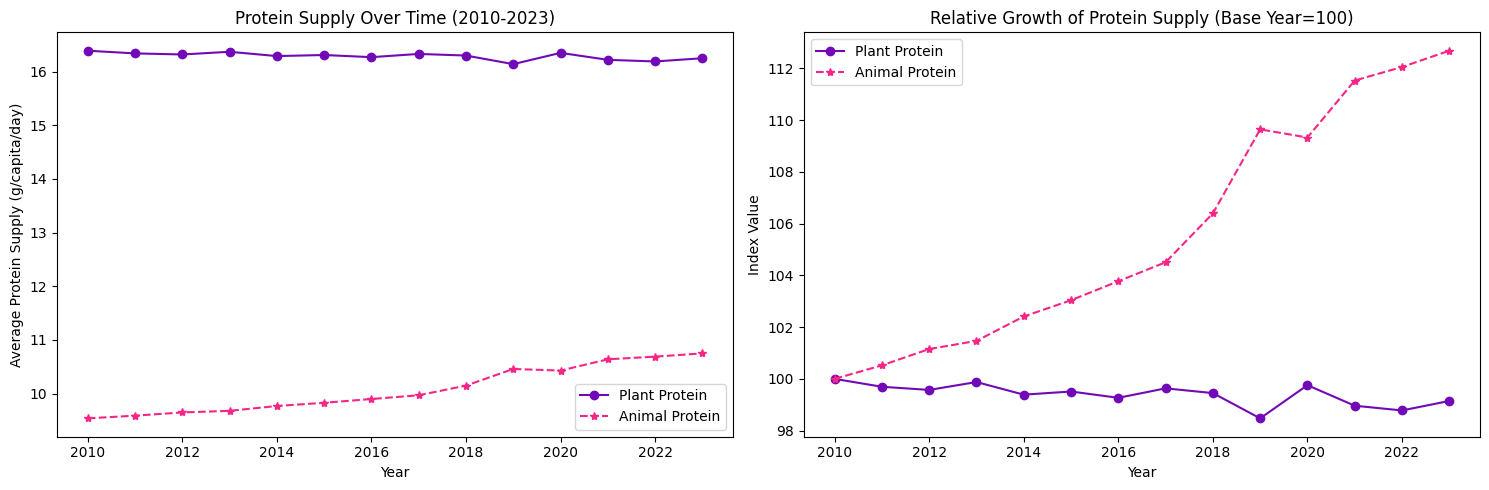

In [0]:
#Convert to Pandas
protein_trend_df = protein_trend.toPandas()

#Indexing to view relative growth of protein
base_yr = 100
indexed_df = protein_trend_df.copy()
indexed_df['index_value'] = indexed_df.groupby('Food_Type')['Avg_Protein_Supply'].transform(lambda x: x / x.iloc[0] * base_yr)

#Visualization
fig, axes = plt.subplots(1,2, figsize=(15,5))

## Original Protein Trend Plot
#Filter data
plant_df = protein_trend_df[protein_trend_df['Food_Type'] == 'plant-based']
animal_df = protein_trend_df[protein_trend_df['Food_Type'] == 'animal-based']

axes[0].plot(plant_df['Year'], plant_df['Avg_Protein_Supply'], marker='o', linestyle='-', color="#7209B7", label='Plant Protein')
axes[0].plot(animal_df['Year'], animal_df['Avg_Protein_Supply'], marker='*', linestyle='--', color="#F72585", label='Animal Protein')
axes[0].set_title('Protein Supply Over Time (2010-2023)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Protein Supply (g/capita/day)')
axes[0].legend()

## Indexed Growth Plot
plant_index = indexed_df[indexed_df['Food_Type'] == 'plant-based']
animal_index = indexed_df[indexed_df['Food_Type'] == 'animal-based']

axes[1].plot(plant_index['Year'], plant_index['index_value'], marker='o', linestyle='-', color="#7209B7", label='Plant Protein')
axes[1].plot(animal_index['Year'], animal_index['index_value'], marker='*', linestyle='--', color="#F72585", label='Animal Protein')
axes[1].set_title('Relative Growth of Protein Supply (Base Year=100)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Index Value')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Animal vs Plant Protein Supply
The figure showed temporal trends of plant-based and animal-based protein supply from 2010 to 2023, alongside the indexed relative growth of the respective categories using 2010 as the baseline year. Based on the left panel, plant-based protein dominated the protein source, consistently remained at approximately 16.5 g/capita/day throughout the observed period. In contrast, animal-based protein supply was significantly lower than the aforementioned protein group but an upward trend was observed over time. Langyan et al. (2022) confirmed that more than half of the existing sources of global dietary protein is dominated by plant sources. This may be mainly due to accessibility and sustainability of plant-based proteins whereby livestock farming incurs a higher demand on land, water and energy resources (GEA Group, 2018). 

Although the level of animal-based protein supply is significantly lower than plant-based protein supply, the indexed growth plot revealed a noticeable increase in animal-based protein while plant-derived protein remained relatively stable with minimal long-term growth. The findings suggest dietary transition in which people are gradually incorporating more animal proteins into their diet. This is commonly associated with increasing income levels and urbanization, making more animal-derived proteins more accessible (Boland et al., 2013; Henchion et al., 2017). Besides, consumer awareness towards the associated health benefits of consuming meat had also drive the shift of preferences for animal protein (Ismail et al., 2020). Despite this, plant sources will still be the dominant protein source due to the more competitive and stable pricing (McRae et al., 2026). This is supported by the stable plant-based protein supply observed which also highlights the continued importance of cereals and pulses as foundational dietary stables across the globe. 

**References:**
1. Boland, M. J., Rae, A. N., Vereijken, J. M., Meuwissen, M. P. M., Fischer, A. R. H., van Boekel, M. A. J. S., Rutherfurd, S. M., Gruppen, H., Moughan, P. J., & Hendriks, W. H. (2013). The future supply of animal-derived protein for human consumption. Trends in Food Science & Technology, 29(1), 62–73. https://doi.org/10.1016/j.tifs.2012.07.002
2. GEA Group (2018, August 24). The protein challenge. gea.com. https://www.gea.com/en/stories/protein-challenge/
3. Henchion, M., Hayes, M., Mullen, A., Fenelon, M., & Tiwari, B. (2017). Future Protein Supply and Demand: Strategies and Factors Influencing a Sustainable Equilibrium. Foods, 6(7), 53. https://doi.org/10.3390/foods6070053
4. Ismail, B. P., Senaratne-Lenagala, L., Stube, A., & Brackenridge, A. (2020). Protein demand: review of plant and animal proteins used in alternative protein product development and production. Animal Frontiers, 10(4), 53–63. https://doi.org/10.1093/af/vfaa040
5. Langyan, S., Yadava, P., Khan, F. N., Dar, Z. A., Singh, R., & Kumar, A. (2022). Sustaining Protein Nutrition Through Plant-Based Foods. Frontiers in Nutrition, 8(772573). https://doi.org/10.3389/fnut.2021.772573
6. McRae, C., Saarijärvi, H., Nevalainen, J., Fogelholm, M., Ma, Y., & Dubé, L. (2026). Plant-based protein foods are less sensitive to price changes than animal-based ones, with differences across income and education levels. Communications Sustainability, 1(1). https://doi.org/10.1038/s44458-026-00040-y


#### 4.4 Top Countries for Animal-Based and Plant-Based Protein Supply
The top 10 countries with the highest average supply are identified for animal-based and plant-based proteins, respectively. The main objective is to examine the regional differences in protein consumption patterns.

In [0]:
# Query 4: Top 10 Countries by Animal Protein Supply
animal_trend = spark.sql("""

SELECT Area, ROUND(AVG(Value),2) AS Avg_Animal_Protein_Supply
FROM food
WHERE Element = 'Protein supply quantity (g/capita/day)'
AND Food_Type = 'animal-based'
GROUP BY Area
ORDER BY Avg_Animal_Protein_Supply DESC
LIMIT 10

""")
display(animal_trend)

Area,Avg_Animal_Protein_Supply
Tonga,26.19
"China, Hong Kong SAR",25.76
Iceland,23.41
"China, Macao SAR",22.43
Nauru,20.72
Marshall Islands,20.52
French Polynesia,20.08
Samoa,19.76
United States of America,19.44
Australia,18.99


In [0]:
# Query 5: Top 10 Countries by Plant Protein Supply
plant_trend = spark.sql("""

SELECT Area, ROUND(AVG(Value),2) AS Avg_Plant_Protein_Supply
FROM food
WHERE Element = 'Protein supply quantity (g/capita/day)'
AND Food_Type = 'plant-based'
GROUP BY Area
ORDER BY Avg_Plant_Protein_Supply DESC
LIMIT 10

""")
display(plant_trend)

Area,Avg_Plant_Protein_Supply
Ethiopia,33.07
Niger,32.92
Morocco,30.44
Egypt,27.56
Tunisia,26.83
Burkina Faso,26.6
Türkiye,26.17
Algeria,25.69
Serbia,25.65
Azerbaijan,24.4


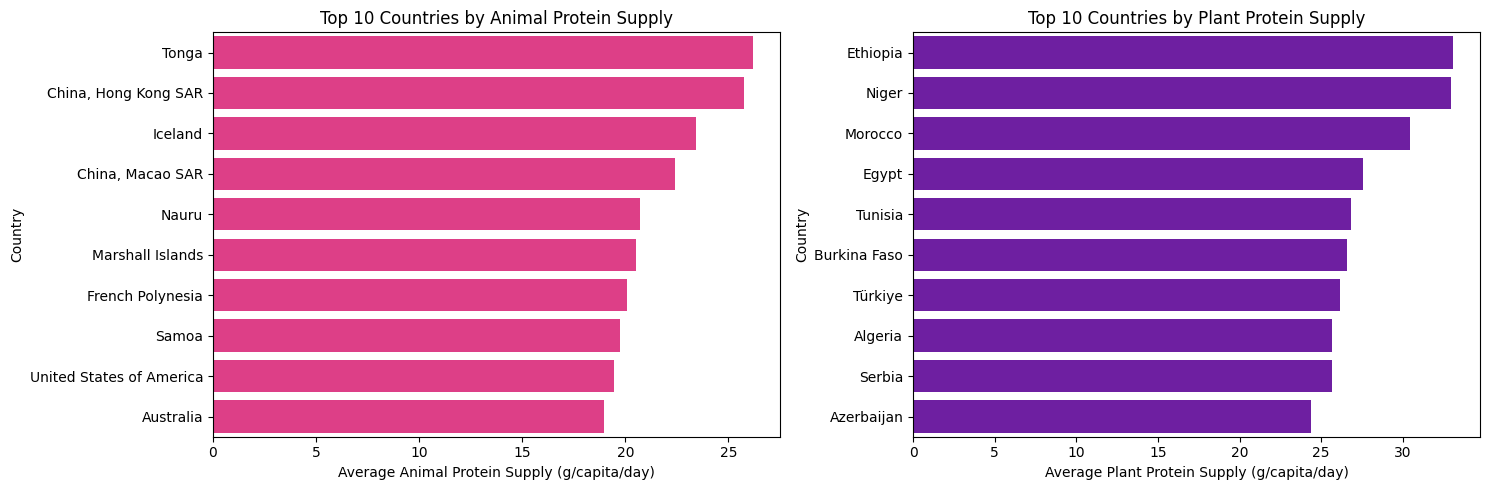

In [0]:
#Convert to Pandas
animal_trend_df = animal_trend.toPandas()
plant_trend_df = plant_trend.toPandas()

#Visualization
fig, axes = plt.subplots(1, 2, figsize=(15,5))
#Animal Protein Supply
sns.barplot(x='Avg_Animal_Protein_Supply', y='Area', data=animal_trend_df, ax=axes[0], color="#F72585")
axes[0].set_title('Top 10 Countries by Animal Protein Supply')
axes[0].set_xlabel('Average Animal Protein Supply (g/capita/day)')
axes[0].set_ylabel('Country')
#Plant Protein Supply
sns.barplot(x='Avg_Plant_Protein_Supply', y='Area', data=plant_trend_df, ax=axes[1], color="#7209B7")
axes[1].set_title('Top 10 Countries by Plant Protein Supply')
axes[1].set_xlabel('Average Plant Protein Supply (g/capita/day)')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

#### Top Countries for Animal vs Plant Proteins
The figure compares the top 10 countries with the highest average animal-based and plant-based protein supplies which revealed distinct regional and dietary differences between the two protein groups. Most countries recorded for highest levels of animal-based protein supply are dominated by island or coastal economies including the Pacific islands, Hong Kong SAR, Iceland, which suggest dependence on marine and seafood-derived dietary systems (Charlton et al., 2016; Steingrímsdóttir et al., 2018). Developed countries such as the United States and Australia were also report among the top countries for animal protein supply. This is mainly driven by the higher average incomes which enable their citizens to afford more protein-rich diets. Ritchie (2019) mentioned that countries with weaker economies are associated with lower meat consumption. Besides, having the dairy industry as the major economic contributor, Australia’s high animal protein diet is closely tied to its domestic agricultural output (Department of Agriculture, Fisheris and Forestry, 2024).  However, consumers are slowly shifting towards plant-based milk alternatives in view of sustainability pressure in recent years (Tulysewski et al., 2024). Interestingly, Hong Kong and Macau outran countries like the US and Australia in terms of meat consumption (Yau et al., 2018). In addition to their high per-capita GDP, the dietary culture of Cantonese often emphasizes on meat across various kind of cooking methods. With its dependence on imported meat, Hong Kong’s position as the major global entrepot had resulted in a steady and continuous supply (Trade and Industry Department, 2026).

In contrast, countries with highest plant-based protein supply were primarily concentrated in North Africa and Sub-Saharan Africa, including Ethiopia, Niger, Morocco, Egypt, Tunisia, and Burkina Faso. These countries are generally more dependent on staples such as cereals, legumes, and nuts as part of their heritage (Badur, 2026; Rufai, 2025). Countries like Morocco, Egypt and Tunisia follows the Mediterranean diet which emphasizes the consumption of high-quality plant food and unsaturated fats with a low intake of red meat (El Rhazi et al., 2012). Whilst for countries like Ethiopia and Nigeria, their dependencies on plant-based protein are mainly driven by cultural traditions, agricultural suitability and affordability (Ogutu et al., 2024). Unlike animal proteins which often requires greater resource input and purchasing power, plant-based protein can be supplied through locally produced crops, thus supporting continuous protein availability. Overall, the contrasting profiles of two protein groups showed how geography, agriculture, trade, and economic development interact to determine whether populations rely more on animal-based or plant-based protein sources.

**References:**
1. Badur, C. (2026, January 10). Why Middle Eastern Food Is One of the Healthiest Cuisines in the World. Holy Pita Best Mediterranean Food in Brooklyn. https://www.holypita.com/s/stories/why-middle-eastern-food-is-one-of-the-healthiest-cuisines-in-the-world
2. Charlton, K. E., Russell, J., Gorman, E., Hanich, Q., Delisle, A., Campbell, B., & Bell, J. (2016). Fish, food security and health in Pacific Island countries and territories: a systematic literature review. BMC Public Health, 16(1). https://doi.org/10.1186/s12889-016-2953-9
3. Department of Agriculture, Fisheris and Forestry. (2024). Dairy in Australia. Agriculture.gov.au. https://www.agriculture.gov.au/agriculture-land/farm-food-drought/meat-wool-dairy/dairy
4. El Rhazi, K., Nejjari, C., Romaguera, D., Feart, C., Obtel, M., Zidouh, A., Bekkali, R., & Gateau, P. B. (2012). Adherence to a Mediterranean diet in Morocco and its correlates: cross-sectional analysis of a sample of the adult Moroccan population. BMC Public Health, 12(1). https://doi.org/10.1186/1471-2458-12-345
5. Ogutu, F. O., Okiko, G., Wanjala, G., Luvitaa, S., Obong’o, B. O., Vriesekoop, F., & Munialo, C. D. (2024). Unlocking the potential of plant‐based foods in sub‐Saharan Africa: a review of the opportunities and challenges. International Journal of Food Science & Technology, 59(8), 5326–5342. https://doi.org/10.1111/ijfs.17327
6. Ritchie, H. (2019, February 4). Which countries eat the most meat? BBC News. https://www.bbc.com/news/health-47057341
7. Rufai, F. (2025, September 25). Plant-Based Eating in Africa: Tradition Meets Modern Health. Healthcoach Africa - Health Information and Advice You Can Trust. https://www.healthcoachafrica.com/plant-based-eating-in-africa-tradition-meets-modern-health/‌‌
8. Steingrímsdóttir, L., Thorkelsson, G., & Eythórsdóttir, E. (2018). Food, Nutrition, and Health in Iceland. Nutritional and Health Aspects of Food in Nordic Countries, 145–177. https://doi.org/10.1016/b978-0-12-809416-7.00006-8‌
9. Trade and Industry Department. (2026, March 19). Hong Kong - Mainland Trade Relations. Tid.gov.hk. https://www.tid.gov.hk/en/our_work/trade_relations/mainland/overview.html‌
10. Tulysewski, G., Hendrie, G. A., Baird, D. L., Umberger, W., & Malek, L. (2024). Factors Influencing Consumption of Animal-Based Dairy and Plant-Based Milk Alternatives in Australia. Sustainability, 16(16), 7168. https://doi.org/10.3390/su16167168‌
11. Yau, Y. Y., Thibodeau, B., & Not, C. (2018). Impact of cutting meat intake on hidden greenhouse gas emissions in an import-reliant city. Environmental Research Letters, 13(6), 064005. https://doi.org/10.1088/1748-9326/aabd45


#### 4.5 Distribution of Calorie Supply Across Food Categories
The distribution of average colorie supply across countries for plant-based foods, animal-based foods, and sugar were evaluated. Unlike previous analyses that emphasized on averages and rankings, this section explored variability, dispersion and cross-country differences in dietary energy composition.

In [0]:
## Query 6: Distribution of Calorie Supply by Food Type
food_supply = spark.sql("""
        
SELECT Area, Food_Type, ROUND(AVG(Value),2) AS avg_calorie_supply
FROM food
WHERE Element = 'Food supply (kcal/capita/day)'
GROUP BY Area, Food_Type

""")
display(food_supply)

Area,Food_Type,avg_calorie_supply
Algeria,plant-based,796.17
Austria,animal-based,147.98
Belize,sugar,395.79
Albania,sugar,227.73
Argentina,animal-based,198.75
Armenia,animal-based,104.84
Barbados,sugar,564.11
Barbados,animal-based,139.79
Bhutan,sugar,140.4
Botswana,sugar,276.12


/home/spark-54db2c97-1d0a-4a2b-8284-e2/.ipykernel/2141/command-7740253745707785-934442265:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Food_Type', y='avg_calorie_supply', data=food_supply_df, palette={'plant-based': "#7209B7", 'animal-based': "#F72585", 'sugar': "#4CC9F0"})


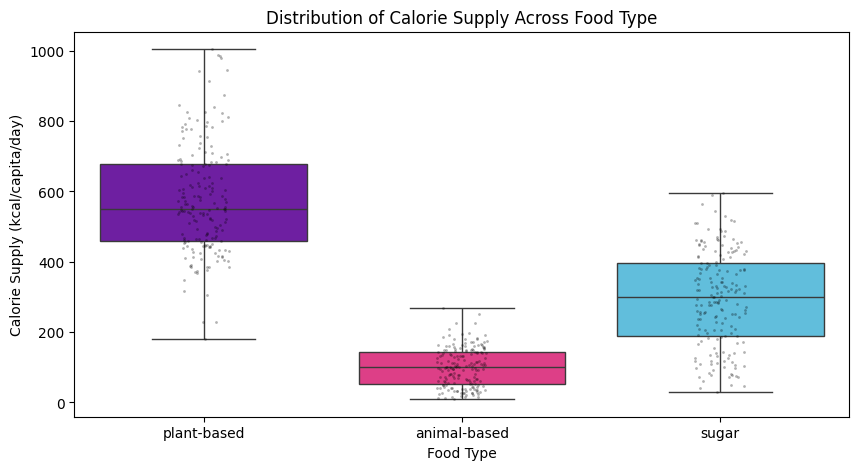

In [0]:
#Convert to Pandas
food_supply_df = food_supply.toPandas()

#Visualization
plt.figure(figsize=(10,5))
sns.boxplot(x='Food_Type', y='avg_calorie_supply', data=food_supply_df, palette={'plant-based': "#7209B7", 'animal-based': "#F72585", 'sugar': "#4CC9F0"})
sns.stripplot(x='Food_Type', y='avg_calorie_supply', data=food_supply_df, color='black', alpha=0.3, size=2, jitter=True)
plt.title('Distribution of Calorie Supply Across Food Type')
plt.xlabel('Food Type')
plt.ylabel('Calorie Supply (kcal/capita/day)')
plt.show()

#### Distribution of Calorie Supply Across Food Categories
The boxplot displays the distribution of average calorie supply across countries for food categories, namely plant-based food, animal-based food, and sugar between 2010 and 2023. Plant-based foods exhibited the highest median calorie supply and the greatest variability across countries. This suggests substantial differences of dietary reliance on plant-derived staples including cereals and pulses. The large interquartile range showed that despite plant-based food serves as the major dietary energy source globally, contributions vary across food systems depending on the type of diet culturally adopted by the country. It is noteworthy that sugar supply demonstrated a relatively balanced and narrower distribution compared to plant-based food. This indicates a consistent presence or consumption of sugar across the globe which may reflect widespread use of sugar in the modern diet. Nevertheless, a slight positive skew is observed with a small number of countries having substantially higher calorie supply from sugar compared to the majority of observations. While sugar has become a common component in the food system, certain countries demonstrate a greater reliance on sugar-rich foods and sweetened products. Furthermore, animal-derived food exhibited the smallest median and distribution range, suggesting that animal-based food generally contribute to only a small proportion of the total dietary energy. Similarly, presence of high-value observations suggests that animal-based calories remain an importance component of specific dietary systems. Overall, the figure highlighted cross-country differences in calorie composition and showed that agricultural structures, food accessibility and consumption patterns shape the dietary energy sources.

### 5.0 Conclusion
This study analyzed the global nutritional supply patterns using from 2010 to 2023, focusing on sugar, protein sources and calorie distribution across food categories. The findings revealed ongoing dietary transition, characterized global sugar supply, gradual growth in animal-based protein supply and steady dominance of plant-derived protein supply. While a downward trend is observed in the global sugar supply, several countries that depend highly on processed food and sugary drinks still exhibit high per-capita sugar supply. Country-level comparisons for protein supply patterns also revealed that a close relation with geography, economic development, agricultural systems, and food accessibility. Plant-based food remained the primary global source of protein and dietary energy while the growth in animal-based protein reflects shifting consumer preferences and increasing dietary diversification.

From industrial perspective, the results suggest several opportunities especially in plant-based protein products such as meat alternatives and protein-enriched functional foods. With consumers increasing interest in affordable and health-conscious food options, plant-based protein markets are expected to remain an important segment within the global food industry. Furthermore, sustainable livestock production could also be a potential segment with increasing demand for animal-based protein. To accommodate the increasing consumer’s awareness on the effect of excessive sugar consumption, food manufacturers can look into the reformulation of products and develop reduced-sugar alternatives in response to these evolving preferences.